In [ ]:
import numpy as np
from HarmonicPotential2D import HarmonicPotential2D


No module named 'trame'

Falling back to a static output.
  warnings.warn(



Solving the variational problem...
Solved the variational problem
Solving the variational problem...
Solved the variational problem


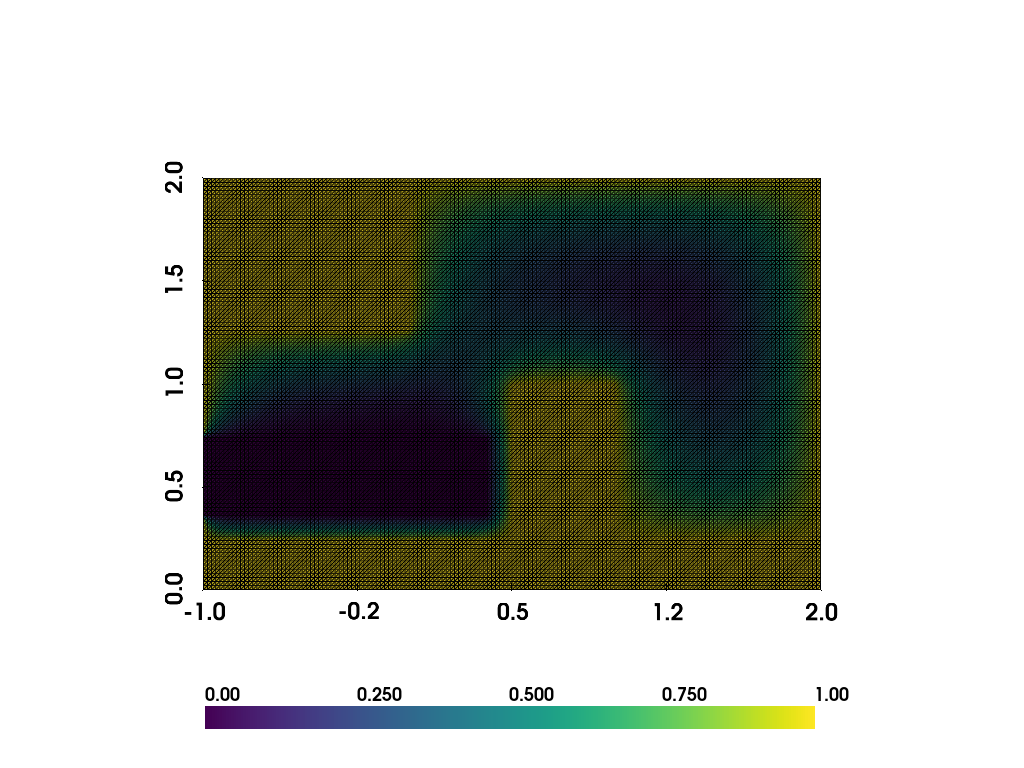

In [ ]:
# Specify the number of triangles in each dimension
num_triangles_x = 150
num_triangles_y = 100

domain_corners = [(-1.0, 0.0), (2.0, 2.0)]
unsafe_boxes = [[(-1.0,0.0), (2.0,0.25)],
                [(0.5,0.25), (1.0,1.0)],
                [(-1.0,1.25), (0.0,2.0)]]
target_box = [[(-1.0,0.35), (0.4,0.75)]]

clbf = HarmonicPotential2D(domain_corners=domain_corners, unsafe_boxes=unsafe_boxes, target_box=target_box, num_triangles_x=num_triangles_x, num_triangles_y=num_triangles_y)
clbf2 = HarmonicPotential2D(domain_corners=domain_corners, unsafe_boxes=unsafe_boxes, target_box=target_box, f_val=-6, num_triangles_x=num_triangles_x, num_triangles_y=num_triangles_y) # Not needed, just aids in visual
clbf2.plot_solution_with_trajectory(show_edges=True)

In [7]:
from math import sin, cos
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


# Constants
g     = 9.81    # Gravitational acceleration (m/s^2)
m     = 0.033    # Mass (kg)
Ixx   = 2.31e-05 # Mass moment of inertia (kg*m^2)
L     = 0.046/np.sqrt(2)   # Arm length (m)

# Returns the desired position, velocity, and acceleration at a given time.
# Trajectory is a step (y changes from 0 to 0.5 at t=1)
#
# t     : Time (seconds), scalar
# return: Desired position & velocity & acceleration, y, z, vy, vz, ay, az
def trajectory(x,t):
    # y,z = find_midpoint(x[0],x[1])
    y = 0
    z = 0
    k = 0.1
    vy, vz = clbf.evaluate_gradient(x[0],x[1])
    if vy**2+vz**2 > 0:
        vy, vz = -vy*k/np.sqrt(vy**2+vz**2),-vz*k/np.sqrt(vy**2+vz**2)
    else:
        vy, vz = -vy, -vz
    # vy = 0
    # vz = 0
    ay = 0
    az = 0

    return y, z, vy, vz, ay, az


# Returns force and moment to achieve desired state given current state.
# Calculates using PD controller.
#
# x     : Current state, [y, z, phi, vy, vz, phidot]
# y_des : desired y
# z_des : desired z
# vy_des: desired y velocity
# vz_des: desired z velocity
# ay_des: desired y acceleration
# az_des: desired z acceleration
# return: Force and moment to achieve desired state
def controller(x, y_des, z_des, vy_des, vz_des, ay_des, az_des):
    Kp_y   = 0.4
    Kv_y   = 1.0
    Kp_z   = 0.4
    Kv_z   = 1.0
    Kp_phi = 18
    Kv_phi = 15

    Kp_y, Kp_z = 0.0, 0.0
    
    phi_c = -1/g * (ay_des + Kv_y * (vy_des - x[3]))# + Kp_y * (y_des - x[0]))
    F = m * (g + az_des + Kv_z * (vz_des - x[4]))# + Kp_z * (z_des - x[1]))
    M = Ixx * (Kv_phi * (-x[5]) + Kp_phi * (phi_c - x[2]))

    return F, M


# Limit force and moment to prevent saturating the motor
# Clamp F and M such that u1 and u2 are between 0 and 1.7658
#
#    u1      u2
#  _____    _____
#    |________|
#
# F = u1 + u2
# M = (u2 - u1)*L
def clamp(F, M):
    u1 = 0.5*(F - M/L)
    u2 = 0.5*(F + M/L)
    
    if u1 < 0 or u1 > 1.7658 or u2 < 0 or u2 > 1.7658:
        print(f'motor saturation {u1} {u2}')
    
    u1_clamped = min(max(0, u1), 1.7658)
    u2_clamped = min(max(0, u2), 1.7658)

    # u1_clamped = u1
    # u2_clamped = u2

    F_clamped = u1_clamped + u2_clamped
    M_clamped = (u2_clamped - u1_clamped) * L

    return F_clamped, M_clamped


# Equation of motion
# dx/dt = f(t, x)
#
# t     : Current time (seconds), scalar
# x     : Current state, [y, z, phi, vy, vz, phidot]
# return: First derivative of state, [vy, vz, phidot, ay, az, phidotdot]
def xdot(t, x):
    # print(t)
    if x[0] < 0.4 and x[1] < 0.75:
        return [0,0,0,0,0,0]
    y_des, z_des, vy_des, vz_des, ay_des, az_des = trajectory(x,t)
    F, M = controller(x, y_des, z_des, vy_des, vz_des, ay_des, az_des)
    F_clamped, M_clamped = clamp(F, M)

    # First derivative, xdot = [vy, vz, phidot, ay, az, phidotdot]
    return [x[3],
            x[4],
            x[5],
            -F_clamped * sin(x[2]) / m,
            F_clamped * cos(x[2]) / m - g,
            M_clamped / Ixx]

def simulate(x0=None):
    if x0 is None:
        x0 = [np.random.uniform(1.4,1.6),
            np.random.uniform(0.3,1.0), 
            np.random.uniform(-0.05,0.05), 
            np.random.uniform(-0.01,0.01), 
            np.random.uniform(-0.01,0.01), 
            np.random.uniform(-0.01,0.01)] # Initial state [y0, z0, phi0, vy0, vz0, phidot0]
    print(x0)
    t_span = [0, 2000]            # Simulation time (seconds) [from, to]

    # Solve for the states, x(t) = [y(t), z(t), phi(t), vy(t), vz(t), phidot(t)]
    sol = solve_ivp(xdot, t_span, x0, method="RK45")
    return sol


# # Plot
# fig, axs = plt.subplots(3)
# axs[0].plot(sol.t, sol.y[0]) # y   vs t
# axs[1].plot(sol.t, sol.y[1]) # z   vs t
# axs[2].plot(sol.t, sol.y[2]) # phi vs t
# plt.show()


[1.5, 0.3, 0, 0, 0, 0]



No module named 'trame'

Falling back to a static output.
  warnings.warn(



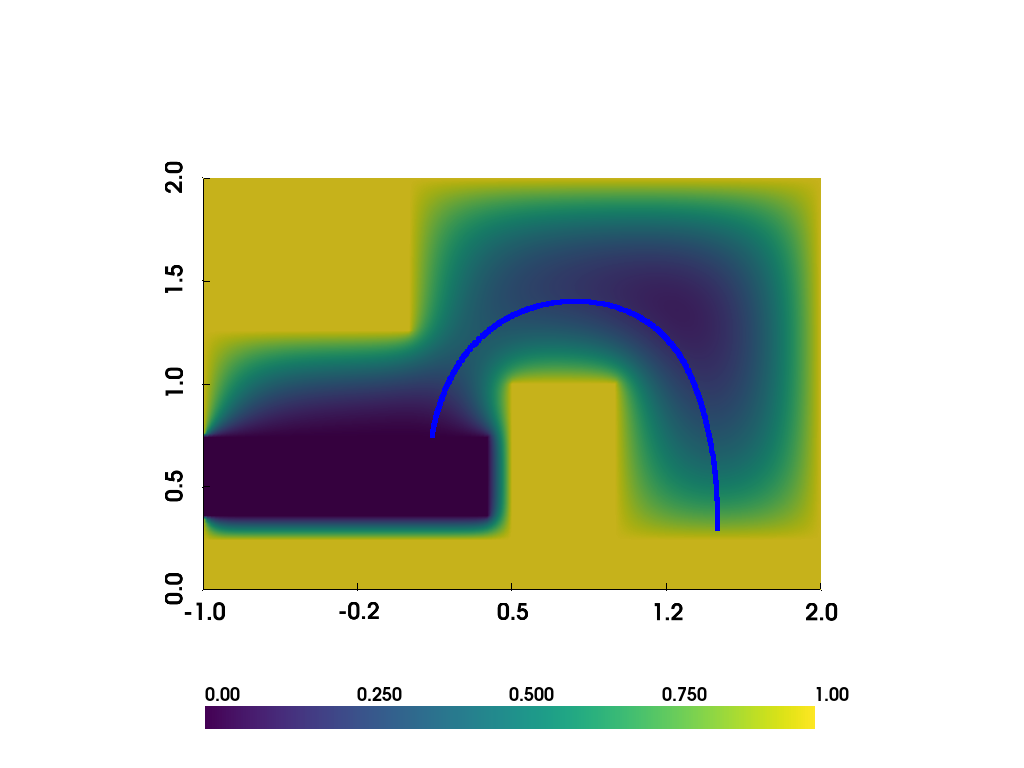

In [8]:
sol = simulate([1.5,0.3,0,0,0,0])
trajs = []
trajs.append(sol.y[:3,:].T)

clbf2.plot_solution_with_trajectory(trajs,show_edges=False)

In [9]:
sol.y[1,:] < 0.75

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [10]:
a = sol.t[sol.y[1,:] < 0.75]
min(a[a>10])

26.210781502368125

[1.4264724996502958, 0.8301570011324821, -0.030997136666353745, -0.004377467526006749, -0.009502585496942679, 0.007333005826880094]
[1.480090074834932, 0.8408297587227829, -0.0178687720337418, 0.004218544159925241, -0.009428589076757069, 0.009833605775217412]
[1.5651079291669516, 0.9327288908452422, -0.008792766709978653, -0.00655952915989735, -0.0011265222904608338, -0.009000245414702287]
[1.4389156571923671, 0.9686556568746845, 0.009861396255777269, -0.004084677475276272, -0.006435345516758529, 0.008893623053309136]
[1.464296691011772, 0.8885993924856597, -0.02345432561162868, -0.008613289495702595, 0.00040454580849306684, 0.005562155719749393]
[1.4275038117069316, 0.5081755190325832, -0.021999337771321893, 0.009311318021692412, -0.005496126802467399, -0.0022579073179415585]
[1.547018563701472, 0.6343035284512268, -0.0025117385196887568, -0.0005084055992965863, -0.009082222303838807, -0.000383909816140629]
[1.4210367976811131, 0.8538438523608223, -0.020355852335321268, -0.00305181083


No module named 'trame'

Falling back to a static output.
  warnings.warn(



22.29814408607622
1.4141393470627202


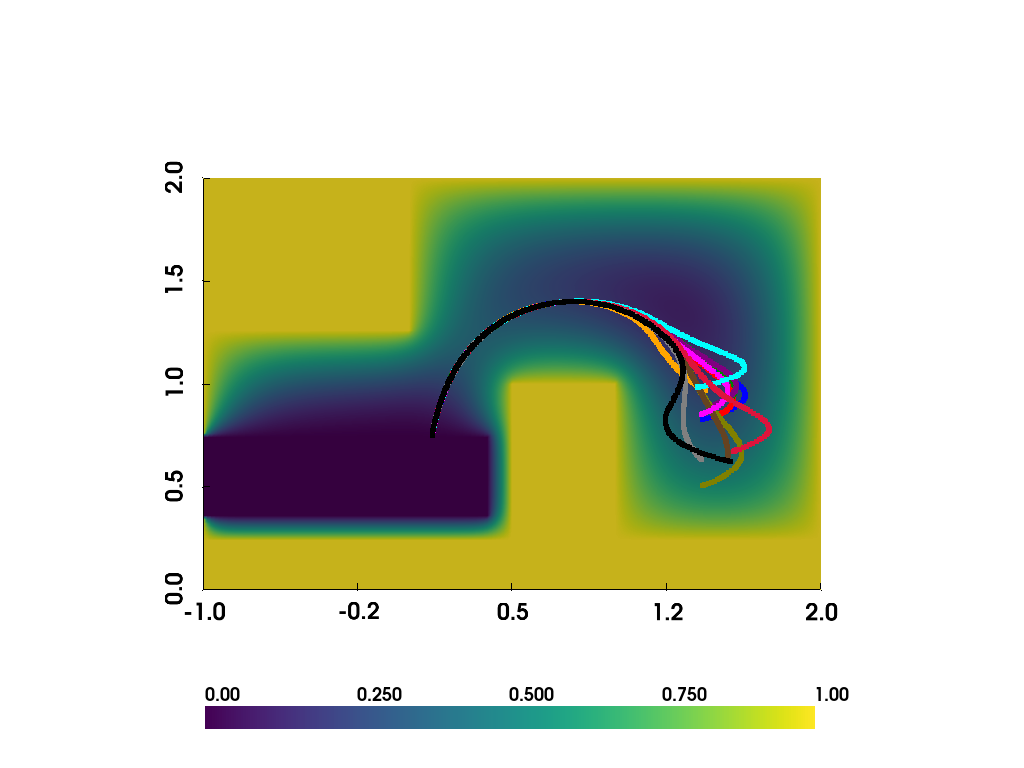

In [11]:
trajs = []
times = []
for i in range(12):
    sol = simulate()
    a = sol.t[sol.y[1,:] < 0.75]
    times.append(min(a[a>10]))
    trajs.append(sol.y[:3,:].T)
print(np.mean(times))
print(np.std(times))
clbf2.plot_solution_with_trajectory(trajs,show_edges=False,fig_name="quad2d_2_sol.eps")